![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [19]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Importación librerías
import numpy as np
import keras 
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from keras import initializers
from keras import optimizers
from keras.models import Sequential, load_model
from keras.layers import Dense
from keras.layers import Dropout
from IPython.display import Markdown, display

from livelossplot import PlotLossesKeras
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scikeras.wrappers import KerasRegressor
from keras.callbacks import EarlyStopping, ModelCheckpoint
import tensorflow as tf
import random
import os
from keras.optimizers import Adam
from keras.layers import BatchNormalization

In [21]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/universityGraduateAdmissions.csv', index_col=0)
data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


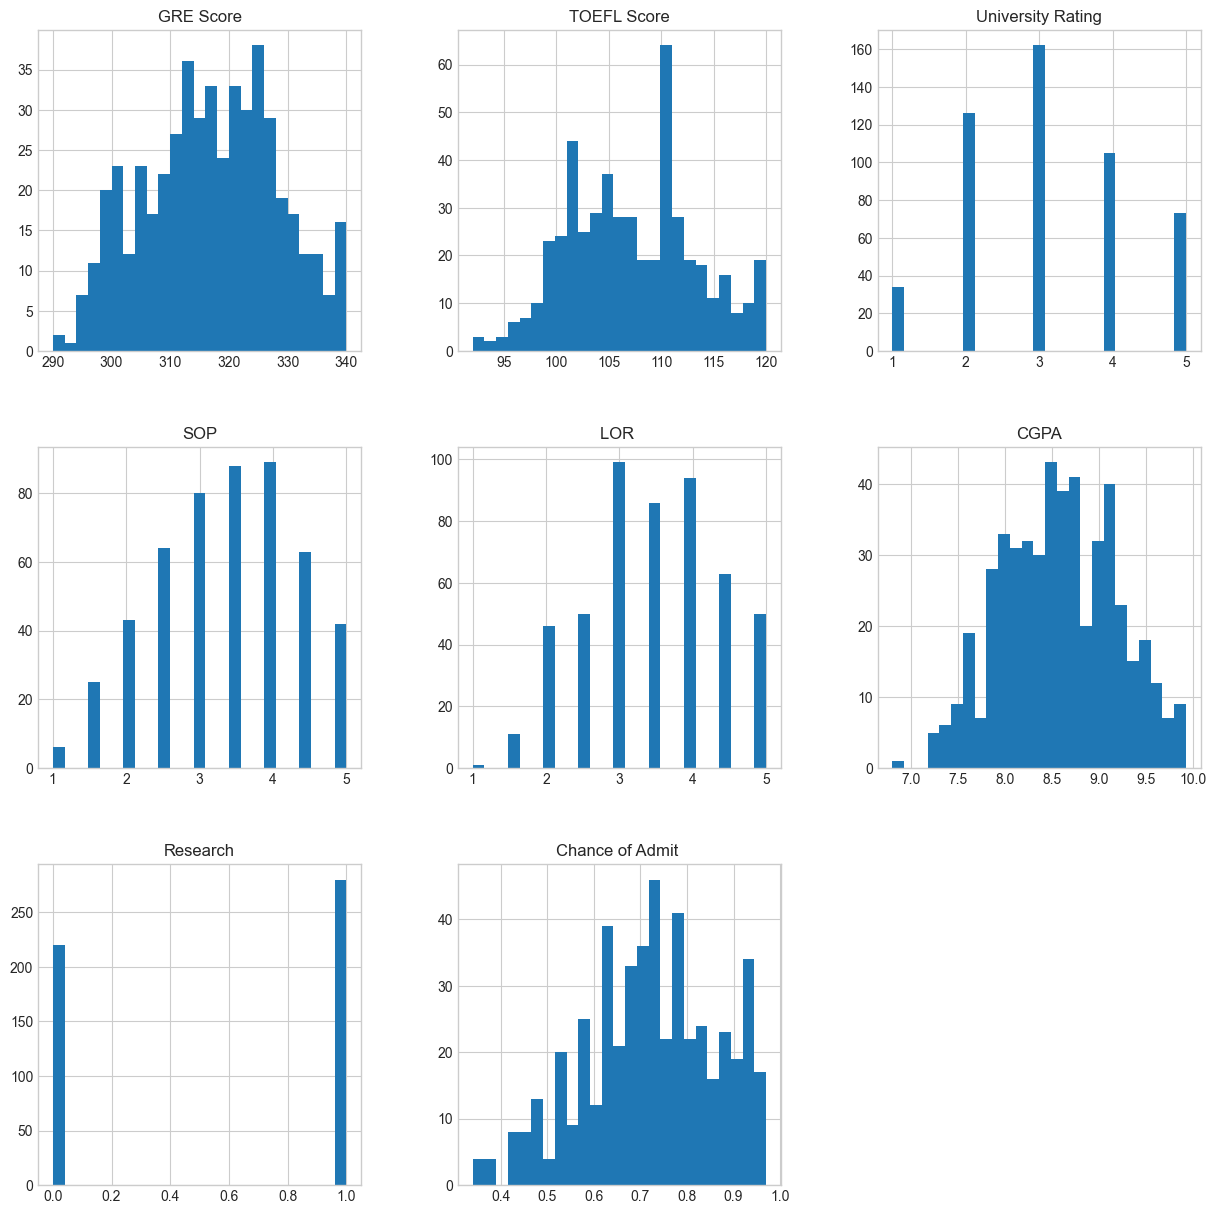

In [22]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [23]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [24]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.3, random_state=22)

In [25]:
#Escalamiento de los datos
scaler = StandardScaler()
scaler.fit(xTrain)       

X_train = pd.DataFrame(data=scaler.transform(xTrain), columns=xTrain.columns, index=xTrain.index)
X_test  = pd.DataFrame(data=scaler.transform(xTest),  columns=xTest.columns,  index=xTest.index)


X_train = np.array(X_train)
Y_train = np.array(yTrain)

X_test = np.array(X_test)
Y_test = np.array(yTest)

# Definición de dimensiones de salida, varaibles de interés
output_var = 1
print(output_var, ' output variables')

# Definición de dimensiones de entrada, varaibles predictoras
dims = X_train.shape[1]
print(dims, 'input variables')

1  output variables
7 input variables


In [26]:
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

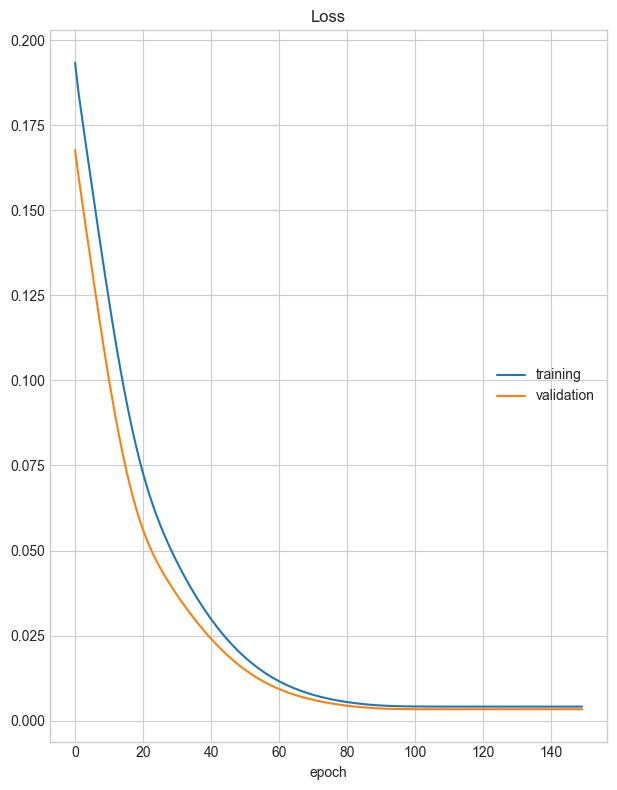

Loss
	training         	 (min:    0.004, max:    0.193, cur:    0.004)
	validation       	 (min:    0.003, max:    0.168, cur:    0.003)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0041 - val_loss: 0.0034
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 

Mejor desempeño: -0.07143181434269913
Mejores parámetros: {'epochs': 150, 'loss': 'mean_squared_error', 'optimizer': 'rmsprop'}
Error Absoluto Medio (MAE): 0.0440
Error Cuadrático Medio (MSE): 0.0034


In [27]:
# Celda 1
def crear_modelo_una_capa(optimizer='adam', loss='mean_squared_error'):
    tf.keras.utils.set_random_seed(SEED) 
    model = Sequential()
    model.add(Dense(output_var, input_shape=(dims,), activation='sigmoid'))
    model.compile(optimizer=optimizer, loss=loss)
    return model

model_wrapper = KerasRegressor(model=crear_modelo_una_capa, verbose=0)

param_grid = {
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'loss': ['mean_squared_error', 'binary_crossentropy'],
    'epochs': [50, 100, 150],
}

grid = GridSearchCV(estimator=model_wrapper, param_grid=param_grid, cv=3, scoring='neg_mean_absolute_error')
grid_result = grid.fit(X_train, Y_train)

best_config = grid_result.best_params_
model_final = crear_modelo_una_capa(optimizer=best_config['optimizer'], loss=best_config['loss'])
model_final.fit(X_train, Y_train, epochs=best_config['epochs'], validation_data=(X_test, Y_test), verbose=1, callbacks=[PlotLossesKeras()])

y_pred = model_final.predict(X_test)
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)

print(f"\nMejor desempeño: {grid_result.best_score_}")
print(f"Mejores parámetros: {grid_result.best_params_}")

print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")

En este punto se realizó una red de una sola capa, teniendo en cuenta que hace referencia únicamente a la capa de salida sin ninguna capa densa intermedia.

* En cuanto a la arquitectura se decidió usar sigmoid en la capa de salida ya que, al tratarse de la probabilidad de aceptación del estudiante, esta se encuentra acotada entre 0 y 1, lo cual coincide exactamente con la cota de esta función de activación y permite obtener predicciones válidas dentro del rango esperado.
* Se utilizó un grid search con validación cruzada de 3 folds con el fin de seleccionar la mejor combinación entre optimizadores, funciones de pérdida y número de épocas de entrenamiento. En cuanto a la función de pérdida, a pesar de ser un problema continuo, se decidió probar tanto MSE como entropía cruzada binaria, ya que al estar la salida acotada entre 0 y 1 podría tratarse de forma similar a una clasificación, la justificación de incluir este parámetro es evaluar si podría tener un buen desempeño bajo este enfoque. Respecto al optimizador, se escogieron los 3 más usados (Adam, SGD y RMSprop) para identificar cuál se ajusta mejor a este problema. Los tamaños de entrenamiento se definieron arbitrariamente, sin elegir cantidades de épocas muy grandes, ya que no se contaba con un early stopping y se quería evitar un gasto computacional innecesario.
* Finalmente, se usó la métrica MAE durante el entrenamiento ya que esta será la primera candidata para el análisis por su interpretabilidad y por la naturaleza de los datos, que no presentan outliers que justifiquen penalizar errores grandes. Sin embargo, a la hora de evaluar el modelo se presentan tanto MAE como MSE, ya que ambas métricas aportan información complementaria sobre el desempeño en este problema.
* En cuanto a los resultados, se obtuvo un MAE de 0.0440, lo que indica que en promedio el modelo presenta un error de esta magnitud en la predicción de la probabilidad de aceptación de cada estudiante. Asimismo, este resultado se obtuvo con 150 epocas mostrando que el modelo al ser tan simple prefiere tener más epocas de entrenamiento siendo el valor superior y escogio el optimizador rmsprop. Finalmente la perdida escogio el MSE ya que a pesar de ser una probabilidad entre 0 y 1, sigue siendo regresión por lo que es mejor que la entropia.

## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

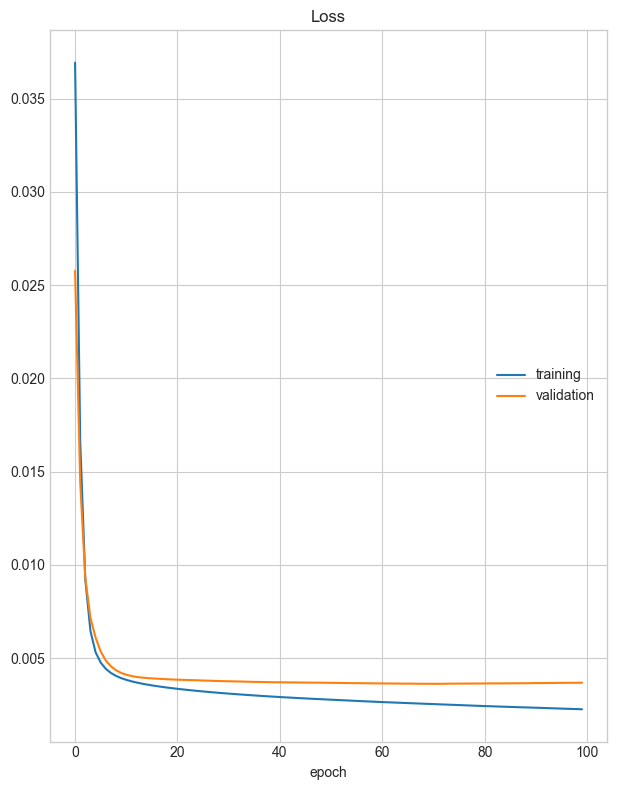

Loss
	training         	 (min:    0.002, max:    0.037, cur:    0.002)
	validation       	 (min:    0.004, max:    0.026, cur:    0.004)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0023 - val_loss: 0.0037
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Mejor desempeño: -0.046921125835649315
Mejores parámetros: {'epochs': 100, 'model__num_neuronas': 128, 'optimizer': 'adam'}
Error Absoluto Medio (MAE): 0.0430
Error Cuadrático Medio (MSE): 0.0037


In [33]:
# Celda 2
def crear_modelo_dos_capas(optimizer='adam', loss='mean_squared_error', num_neuronas=256):
    tf.keras.utils.set_random_seed(SEED) 
    model = Sequential()
    model.add(Dense(num_neuronas, input_shape=(dims,), activation='relu'))
    model.add(Dense(output_var, activation='sigmoid'))
    model.compile(optimizer=optimizer, loss=loss)
    return model

model_wrapper_2_capas = KerasRegressor(model=crear_modelo_dos_capas, verbose=0)

param_grid_2_capas = {
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'epochs': [100, 150],
    'model__num_neuronas': [32, 64, 128,256]
}

grid_2_capas = GridSearchCV(estimator=model_wrapper_2_capas, param_grid=param_grid_2_capas, cv=3, scoring='neg_mean_absolute_error')
grid_result_2_capas = grid_2_capas.fit(X_train, Y_train)

best_config_2_capas = grid_result_2_capas.best_params_
model_final_2_capas = crear_modelo_dos_capas(optimizer=best_config_2_capas['optimizer'], loss='mean_squared_error', num_neuronas=best_config_2_capas['model__num_neuronas'])
model_final_2_capas.fit(X_train, Y_train, epochs=best_config_2_capas['epochs'], validation_data=(X_test, Y_test), verbose=1, callbacks=[PlotLossesKeras()])

y_pred_2_capas = model_final_2_capas.predict(X_test)
mae_2_capas = mean_absolute_error(Y_test, y_pred_2_capas)
mse_2_capas = mean_squared_error(Y_test, y_pred_2_capas)

print(f"\nMejor desempeño: {grid_result_2_capas.best_score_}")
print(f"Mejores parámetros: {grid_result_2_capas.best_params_}")

print(f"Error Absoluto Medio (MAE): {mae_2_capas:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_2_capas:.4f}")


En este punto se realizó una red con 2 capas, una oculta y la de salida.

* En cuanto a la arquitectura, la capa oculta utiliza la activación relu por ser la función estándar en capas intermedias debido a su eficiencia computacional y a que evita el problema del vanishing gradient. La capa de salida mantiene sigmoid por la misma razón explicada en el Punto 1: la variable objetivo está acotada entre 0 y 1, por lo que esta función garantiza predicciones dentro del rango válido.

* Se realizó un grid search con la misma validación cruzada de 3 folds con el fin de optimizar los hiperparámetros. En cuanto a la función de pérdida, se decidió mantener fija MSE a diferencia del Punto 1, ya que en el punto anterior el grid search seleccionó esta función como la mejor opción, por lo que se concluyó que es preferible fijarla directamente, a pesar de la hipótesis mencionada anteriormente sobre que la entropía cruzada binaria podría beneficiarse por el tipo de salida acotada en [0,1]. Esto además permite reducir el costo computacional de las iteraciones. En cuanto al optimizador, se mantuvieron Adam, SGD y RMSprop por ser los más usados en este tipo de problemas. Los tamaños de entrenamiento se redujeron, ya que en el Punto 1 el óptimo fue de 150 épocas, así que solo se dejaron los 2 niveles más altos (100 y 150) para reducir la cantidad de iteraciones. Finalmente, al incorporar la capa oculta, se decidió agregar el número de neuronas como hiperparámetro, explorando los valores 32, 64, 128 y 256, con el fin de cubrir arquitecturas pequeñas y grandes; dado que se trata de una sola capa oculta y un dataset de 500 datos, conviene explorar ambos extremos ya que no hay certeza de cuál capacidad encaja mejor con el dataset.

* Al igual que en el Punto 1, se usó MAE como métrica de selección durante el grid search por su mayor interpretabilidad y por la ausencia de outliers severos en los datos, mientras que en la evaluación final se reportan tanto MAE como MSE para tener una visión complementaria del desempeño.

* En cuanto a los resultados, se obtuvo un MAE de 0.0430, lo que representa una mejora respecto al modelo de una sola capa del Punto 1. Esto evidencia que la incorporación de una capa oculta con activación no lineal permite al modelo capturar relaciones más complejas entre las variables predictoras y la probabilidad de admisión. Sin embargo, la mejora es de apenas 0.010, lo que sugiere que el modelo cuenta con pocos datos y que incluso con una sola capa ya se estaban capturando la mayoría de las interacciones relevantes para la predicción, por lo que las mejoras adicionales serán muy marginales y podrían incluso llevar a sobreajuste. En este caso, el grid search redujo de 150 a 100 épocas y cambió el optimizador a Adam. Finalmente, se escogieron 128 neuronas, lo que sugiere una preferencia por una capacidad relativamente alta, posiblemente por contar con una sola capa oculta que debe asumir toda la representación no lineal del problema.

## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

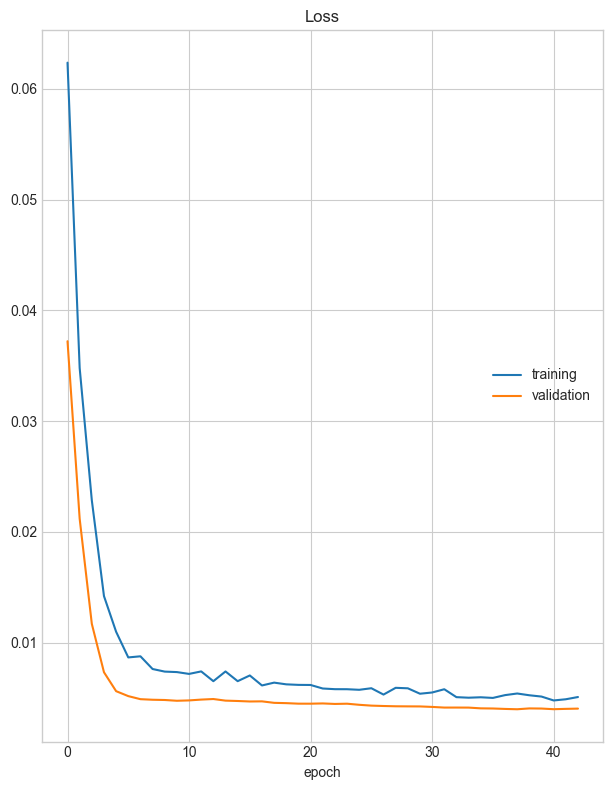

Loss
	training         	 (min:    0.005, max:    0.062, cur:    0.005)
	validation       	 (min:    0.004, max:    0.037, cur:    0.004)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.0051 - val_loss: 0.0041


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Mejor desempeño: -0.046207256097141956
Mejores parámetros: {'epochs': 100, 'model__num_neuronas': 32, 'optimizer': 'adam'}
Error Absoluto Medio (MAE): 0.0477
Error Cuadrático Medio (MSE): 0.0040


In [34]:
# Celda 3
def crear_modelo_multi_capa(optimizer='adam', loss='mean_squared_error', num_neuronas=256):
    tf.keras.utils.set_random_seed(SEED) 
    model = Sequential()
    model.add(Dense(num_neuronas, input_shape=(dims,), activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(num_neuronas,activation='relu'))
    model.add(Dropout(0.1))

    model.add(Dense(output_var, activation='sigmoid'))

    model.compile(optimizer=optimizer, loss=loss)
    return model

model_wrapper_multi = KerasRegressor(model=crear_modelo_multi_capa, verbose=0)


param_grid_multi = {
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'epochs': [100, 150],
    'model__num_neuronas': [32, 64, 128,256]
}

early_stop = EarlyStopping(monitor='val_loss', patience=5, verbose=0) 
fBestModel = 'best_model.h5'
best_model = ModelCheckpoint(fBestModel, verbose=0, save_best_only=True)

grid_multi = GridSearchCV(estimator=model_wrapper_multi, param_grid=param_grid_multi, cv=3, scoring='neg_mean_absolute_error')
grid_result_multi = grid_multi.fit(X_train, Y_train, validation_data=(X_test, Y_test), callbacks=[early_stop])
best_config_multi = grid_result_multi.best_params_

model_final_multi = crear_modelo_multi_capa(optimizer=best_config_multi['optimizer'], loss='mean_squared_error', num_neuronas=best_config_multi['model__num_neuronas'])
model_final_multi.fit(X_train, Y_train, epochs=300, validation_data=(X_test, Y_test), verbose=1, callbacks=[best_model, early_stop, PlotLossesKeras()])
mejor_modelo = load_model('best_model.h5')

y_pred_multi = mejor_modelo.predict(X_test)
mae_multi = mean_absolute_error(Y_test, y_pred_multi)
mse_multi = mean_squared_error(Y_test, y_pred_multi)

print(f"\nMejor desempeño: {grid_result_multi.best_score_}")
print(f"Mejores parámetros: {grid_result_multi.best_params_}")

print(f"Error Absoluto Medio (MAE): {mae_multi:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_multi:.4f}")

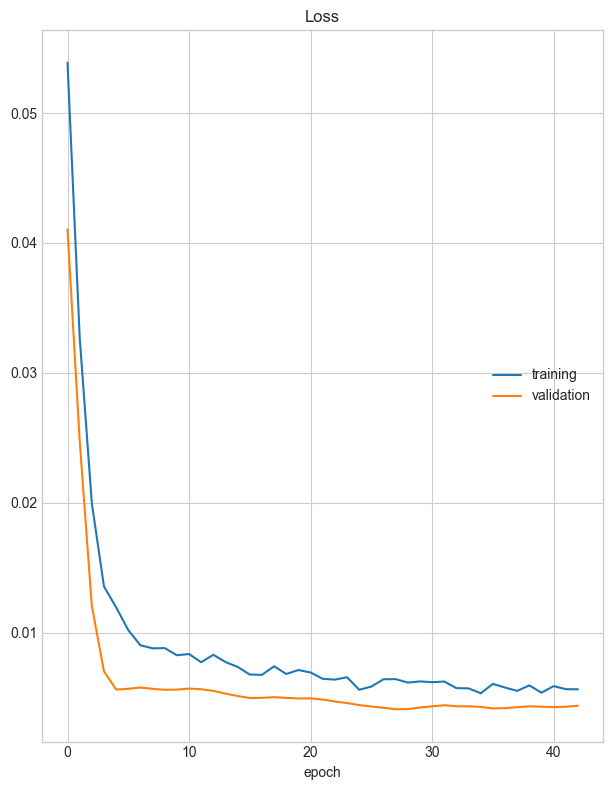

Loss
	training         	 (min:    0.005, max:    0.054, cur:    0.006)
	validation       	 (min:    0.004, max:    0.041, cur:    0.004)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0056 - val_loss: 0.0044


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Mejor desempeño CV: -0.0476
Mejores parámetros: {'epochs': 100, 'model__num_layers': 4, 'model__num_neuronas': 32, 'optimizer': 'adam'}
Error Absoluto Medio (MAE): 0.0485
Error Cuadrático Medio (MSE): 0.0041


In [37]:
# Celda 3 
def crear_modelo_multi_capa_v2(optimizer='adam', loss='mean_squared_error', 
                                num_neuronas=64, num_layers=3, dropout_rate=0.2):
    tf.keras.utils.set_random_seed(SEED)
    model = Sequential()
    
    # Primera capa
    model.add(Dense(num_neuronas, input_shape=(dims,), activation='relu'))
    model.add(Dropout(dropout_rate))
    
    # Capas ocultas adicionales
    for _ in range(num_layers - 1):
        model.add(Dense(num_neuronas, activation='relu'))
        model.add(Dropout(dropout_rate))
    
    # Capa de salida (sigmoid porque es probabilidad en [0,1])
    model.add(Dense(output_var, activation='sigmoid'))
    
    model.compile(optimizer=optimizer, loss=loss)
    return model

model_wrapper_multi_v2 = KerasRegressor(model=crear_modelo_multi_capa_v2, verbose=0)

param_grid_multi_v2 = {
    'optimizer': ['adam', 'sgd', 'rmsprop'],
    'epochs': [100, 150],
    'model__num_neuronas': [32, 64, 128, 256],
    'model__num_layers': [3, 4],
}

early_stop = EarlyStopping(monitor='val_loss', patience=15, 
                           restore_best_weights=True, verbose=0)
fBestModel = 'best_model_v2.h5'
best_model_cb = ModelCheckpoint(fBestModel, verbose=0, save_best_only=True)

grid_multi_v2 = GridSearchCV(
    estimator=model_wrapper_multi_v2, 
    param_grid=param_grid_multi_v2, 
    cv=3, 
    scoring='neg_mean_absolute_error'
)
grid_result_multi_v2 = grid_multi_v2.fit(X_train, Y_train)
best_config_multi_v2 = grid_result_multi_v2.best_params_

model_final_multi_v2 = crear_modelo_multi_capa_v2(
    optimizer=best_config_multi_v2['optimizer'],
    loss='mean_squared_error',
    num_neuronas=best_config_multi_v2['model__num_neuronas'],
    num_layers=best_config_multi_v2['model__num_layers'],
)
model_final_multi_v2.fit(
    X_train, Y_train,
    epochs=300,
    validation_data=(X_test, Y_test),
    verbose=1,
    callbacks=[best_model_cb, early_stop, PlotLossesKeras()]
)
mejor_modelo2 = load_model('best_model_v2.h5')

y_pred_multi_v2 = mejor_modelo2.predict(X_test)
mae_multi2 = mean_absolute_error(Y_test, y_pred_multi_v2)
mse_multi2 = mean_squared_error(Y_test, y_pred_multi_v2)

print(f"\nMejor desempeño CV: {grid_result_multi_v2.best_score_:.4f}")
print(f"Mejores parámetros: {grid_result_multi_v2.best_params_}")
print(f"Error Absoluto Medio (MAE): {mae_multi2:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse_multi2:.4f}")

En este punto se realizaron 2 variantes de redes neuronales multicapa, ambas con dropout y early stopping, con el fin de evaluar cómo responde el modelo al introducir mecanismos de regularización y arquitecturas más complejas. La primera variante mantiene la misma base del Punto 2 agregando solo los mecanismos solicitados, mientras que la segunda busca optimizacion de capas.

**Variante 1: misma base del Punto 2 con dropout y early stopping**
 
* En cuanto a la arquitectura, se replicó la red del Punto 2 (capa oculta con relu + capa de salida con sigmoid) agregando una segunda capa oculta y dropout intercalado entre las capas. Se utilizó dropout de 0.2 en la primera capa y 0.1 en la segunda, decreciendo hacia la salida para no apagar demasiada información cerca de la predicción final.

* Se mantuvo el mismo grid search que en el Punto 2 (mismos optimizadores, épocas y número de neuronas) para que la comparación fuera lo más justa posible y las diferencias en desempeño se atribuyan exclusivamente a la incorporación de la capa adicional, el dropout y el early stopping.

* El early stopping se configuró con patience=5 sobre val_loss, lo que detiene el entrenamiento si no hay mejora en 5 épocas consecutivas. Adicionalmente, se utilizó ModelCheckpoint para guardar el mejor modelo durante el entrenamiento, garantizando que se reporten los pesos óptimos y no los de la última época.

* En cuanto a los resultados, se obtuvo un MAE de 0.0477, un desempeño ligeramente peor que el del modelo de 2 capas (0.0430). Esto es podría a llegar a tener sentido debido que el dropout y el early stopping son mecanismos para combatir el sobreajuste, pero el modelo del Punto 2 no presentaba sobreajuste relevante dado el tamaño reducido del dataset. Por lo que, aplicar regularización donde no hace falta sacrifica capacidad del modelo sin obtener beneficio a cambio.

**Variante 2: arquitectura profunda con búsqueda extendida**

* En esta variante se extendió la arquitectura permitiendo entre 3 y 4 capas ocultas, manteniendo el mismo dropout en todas las capas para simplificar la configuración y eliminar variaciones arbitrarias entre niveles. La idea es evaluar si una mayor profundidad permite extraer patrones adicionales que las arquitecturas más simples no estaban capturando.

* En el grid search se itero num_layers como hiperparámetro adicional (3 y 4 capas), manteniendo los mismos rangos del Punto 2 para optimizador, épocas y número de neuronas. Adicionalmente, se aumentó el patience del early stopping a 15 épocas para evitar cortes prematuros en datasets pequeños donde la curva de validación tiende a tener fluctuaciones.

* En la fase final se entrenó hasta un máximo de 300 épocas con early stopping activo, dándole margen al modelo para converger antes de cortar para ver si a la larga podia tener mejor desempeño.

* En cuanto a los resultados, se obtuvo un MAE de 0.0485, un valor un poco peor al de la Variante 1 y al del Punto 2. Es por esta razón que se realizo 2 variaciones en este punto, ya que los resultados confirman la hipótesis planteada al final del Punto 2, el modelo ha alcanzado un techo de desempeño sobre este dataset. Ni añadir más capas, ni explorar arquitecturas más profundas, ni ajustar finamente los hiperparámetros logran extraer mejoras significativas e incluso podran empeorar el modelo complejizandolo en un dataset pequeño, esta información no permite obtener relaciones adicionales de los datos, ya que con una arquitectura simple es suficiente para identificarlos.

**Conclusión del punto**

Ambas variantes ilustran un mismo fenómeno desde ángulos distintos, la Variante 1 muestra que añadir regularización a un modelo que no la necesita lo perjudica ligeramente, mientras que la Variante 2 muestra que profundizar la arquitectura no aporta capacidad útil cuando el dataset ya está siendo bien modelado por arquitecturas simples. En este caso el problema no demanda más capacidad de la que ya ofrece el modelo del Punto 2.

## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

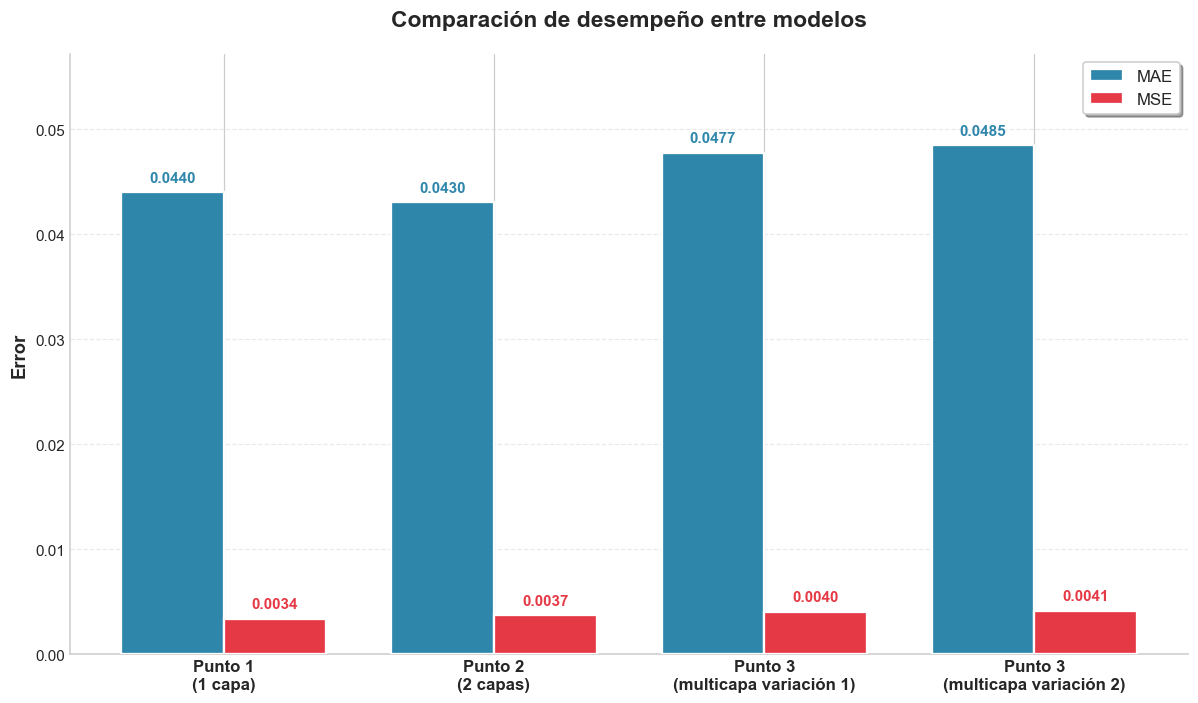


═══════════════════════════════════════════════════════
                 Resumen de desempeño                  
═══════════════════════════════════════════════════════
Modelo                                   MAE      MSE
───────────────────────────────────────────────────────
Punto 1 (1 capa)                      0.0440   0.0034  
Punto 2 (2 capas)                     0.0430   0.0037 ★
Punto 3 (multicapa variación 1)       0.0477   0.0040  
Punto 3 (multicapa variación 2)       0.0485   0.0041  
═══════════════════════════════════════════════════════


In [47]:
# Celda 4
modelos = ['Punto 1\n(1 capa)', 'Punto 2\n(2 capas)', 'Punto 3\n(multicapa variación 1)', 'Punto 3\n(multicapa variación 2)']
mae_vals = [mae, mae_2_capas, mae_multi,mae_multi2]
mse_vals = [mse, mse_2_capas, mse_multi,mse_multi2]
mejor_idx = int(np.argmin(mae_vals))

x = np.arange(len(modelos))
ancho = 0.38

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(11, 6.5), dpi=110)

color_mae = '#2E86AB'
color_mse = '#E63946'

barras_mae = ax.bar(x - ancho/2, mae_vals, ancho, label='MAE',
                    color=color_mae, edgecolor='white', linewidth=1.5, zorder=3)
barras_mse = ax.bar(x + ancho/2, mse_vals, ancho, label='MSE',
                    color=color_mse, edgecolor='white', linewidth=1.5, zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=11, fontweight='bold')
ax.set_ylabel('Error', fontsize=12, fontweight='bold')
ax.set_title('Comparación de desempeño entre modelos',
             fontsize=15, fontweight='bold', pad=18)
ax.legend(fontsize=11, loc='upper right', frameon=True,
          fancybox=True, shadow=True)
ax.grid(axis='y', alpha=0.4, linestyle='--', zorder=0)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
ax.set_ylim(0, max(max(mae_vals), max(mse_vals)) * 1.18)


for barras, color in [(barras_mae, color_mae), (barras_mse, color_mse)]:
    for b in barras:
        h = b.get_height()
        ax.annotate(f'{h:.4f}',
                    xy=(b.get_x() + b.get_width() / 2, h),
                    xytext=(0, 5), textcoords='offset points',
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold', color=color)


plt.tight_layout()
plt.show()

# Tabla resumen
print("\n" + "═" * 55)
print(f"{'Resumen de desempeño':^55}")
print("═" * 55)
print(f"{'Modelo':<35} {'MAE':>8} {'MSE':>8}")
print("─" * 55)
for nombre, m, s in zip(modelos, mae_vals, mse_vals):
    nombre_plano = nombre.replace('\n', ' ')
    marca = ' ★' if mae_vals.index(m) == mejor_idx else '  '
    print(f"{nombre_plano:<35} {m:>8.4f} {s:>8.4f}{marca}")
print("═" * 55)

In [51]:
display(Markdown(f"""**Conclusión:** Inicialmente se evaluaron los modelos con 2 métricas, MAE y MSE, para tener una visión más completa del desempeño. Sin embargo, 
                 dado que el MAE es más interpretable, cada punto representa una unidad de error promedio en la misma escala de la variable objetivo. Además, el problema no enfrenta outliers severos, 
                 lo que hace que no sea necesario penalizar errores grandes como lo haría el MSE. Se optó por el MAE como métrica principal para determinar el mejor modelo. Teniendo 
                 esto en cuenta, el mejor modelo es **{modelos[mejor_idx]}** con un valor de **{mae_vals[mejor_idx]:.4f}**. Esto se interpreta como que, en promedio, 
                 el modelo comete un error de aproximadamente **{mae_vals[mejor_idx]:.4f}** unidades al predecir la probabilidad de admisión. Seguido de este modelo, 
                 el modelo del Punto 1 (1 capa) mostró un desempeño muy cercano con un MAE de **{mae:.4f}**, apenas 0.0010 unidades por encima del mejor modelo. En cuanto a estos modelos, al ser un dataset con solo 500 datos, la adición de capas 
                 adicionales, regularización y optimización de hiperparámetros no ayuda a mejorar el desempeño, ya que un modelo simple como el de 2 capas logra capturar la mayor parte de las 
                 relaciones entre las variables, además de que aumentar la complejidad sobre un dataset tan pequeño incrementa el riesgo de sobreajuste. Por lo que complejizar el modelo con más capas y ajuste de dropout no 
                 aporta una mejora significativa. Por otro lado, el peor modelo es la variación 2 del multicapa, lo cual evidencia que al añadir más capas y mecanismos de regularización (dropout y early stopping) sobre un dataset tan pequeño, 
                 el modelo no logra extraer información adicional útil y termina generalizando peor que arquitecturas más simples, reflejándose en un MAE más alto.
                 
                 \n Por otra parte, se sustenta que los modelos son muy parecidos debido a que al analizar el MSE el mejor modelo ya no sería el de 2 capas sino el del Punto 1 (1 capa) con un MSE de **{mse:.4f}**, frente al **{mse_2_capas:.4f}** del modelo de 2 capas. Esto indica que el modelo de una sola capa, al ser más restrictivo (equivalente a una regresión logística), 
                 tiende a producir predicciones más conservadoras cercanas a la media, lo que evita errores extremos y reduce el MSE, aunque sacrifica precisión promedio teniendo mayor MAE. En cambio, el modelo de 2 capas, al tener mayor capacidad, ajusta mejor en promedio (menor MAE) 
                 pero ocasionalmente comete errores más grandes que penalizan el MSE. Además, al ser errores muy pequeños en ambos modelos, esto permite indicar que tienen un desempeño 
                 muy similar y que la elección entre ellos podría basarse en otros factores como la interpretabilidad, la eficiencia computacional o la preferencia por un modelo más simple 
                 frente a uno más complejo. En este caso, dado que el modelo de 2 capas tiene un MAE ligeramente mejor y sigue siendo una arquitectura simple, podría ser la opción preferida para este dataset específico. De igual
                 forma, se podría considerar el modelo de 1 capa si se prioriza evitar predicciones extremas (menor MSE) o si se valora la máxima simplicidad e interpretabilidad. En resumen, ambos modelos son opciones válidas y la elección entre ellos dependerá de las prioridades y consideraciones 
                 específicas del caso de uso."""))

**Conclusión:** Inicialmente se evaluaron los modelos con 2 métricas, MAE y MSE, para tener una visión más completa del desempeño. Sin embargo, 
                 dado que el MAE es más interpretable, cada punto representa una unidad de error promedio en la misma escala de la variable objetivo. Además, el problema no enfrenta outliers severos, 
                 lo que hace que no sea necesario penalizar errores grandes como lo haría el MSE. Se optó por el MAE como métrica principal para determinar el mejor modelo. Teniendo 
                 esto en cuenta, el mejor modelo es **Punto 2
(2 capas)** con un valor de **0.0430**. Esto se interpreta como que, en promedio, 
                 el modelo comete un error de aproximadamente **0.0430** unidades al predecir la probabilidad de admisión. Seguido de este modelo, 
                 el modelo del Punto 1 (1 capa) mostró un desempeño muy cercano con un MAE de **0.0440**, apenas 0.0010 unidades por encima del mejor modelo. En cuanto a estos modelos, al ser un dataset con solo 500 datos, la adición de capas 
                 adicionales, regularización y optimización de hiperparámetros no ayuda a mejorar el desempeño, ya que un modelo simple como el de 2 capas logra capturar la mayor parte de las 
                 relaciones entre las variables, además de que aumentar la complejidad sobre un dataset tan pequeño incrementa el riesgo de sobreajuste. Por lo que complejizar el modelo con más capas y ajuste de dropout no 
                 aporta una mejora significativa. Por otro lado, el peor modelo es la variación 2 del multicapa, lo cual evidencia que al añadir más capas y mecanismos de regularización (dropout y early stopping) sobre un dataset tan pequeño, 
                 el modelo no logra extraer información adicional útil y termina generalizando peor que arquitecturas más simples, reflejándose en un MAE más alto.
                 
                 
 Por otra parte, se sustenta que los modelos son muy parecidos debido a que al analizar el MSE el mejor modelo ya no sería el de 2 capas sino el del Punto 1 (1 capa) con un MSE de **0.0034**, frente al **0.0037** del modelo de 2 capas. Esto indica que el modelo de una sola capa, al ser más restrictivo (equivalente a una regresión logística), 
                 tiende a producir predicciones más conservadoras cercanas a la media, lo que evita errores extremos y reduce el MSE, aunque sacrifica precisión promedio teniendo mayor MAE. En cambio, el modelo de 2 capas, al tener mayor capacidad, ajusta mejor en promedio (menor MAE) 
                 pero ocasionalmente comete errores más grandes que penalizan el MSE. Además, al ser errores muy pequeños en ambos modelos, esto permite indicar que tienen un desempeño 
                 muy similar y que la elección entre ellos podría basarse en otros factores como la interpretabilidad, la eficiencia computacional o la preferencia por un modelo más simple 
                 frente a uno más complejo. En este caso, dado que el modelo de 2 capas tiene un MAE ligeramente mejor y sigue siendo una arquitectura simple, podría ser la opción preferida para este dataset específico. De igual
                 forma, se podría considerar el modelo de 1 capa si se prioriza evitar predicciones extremas (menor MSE) o si se valora la máxima simplicidad e interpretabilidad. En resumen, ambos modelos son opciones válidas y la elección entre ellos dependerá de las prioridades y consideraciones 
                 específicas del caso de uso.